In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [2]:
df = pd.read_excel("breast_cancer_dataset1.xlsx")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
df.shape

(569, 32)

In [4]:
df.columns = [
'id','diagnosis',
'radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean',
'compactness_mean','concavity_mean','concave_points_mean','symmetry_mean','fractal_dimension_mean',
'radius_se','texture_se','perimeter_se','area_se','smoothness_se',
'compactness_se','concavity_se','concave_points_se','symmetry_se','fractal_dimension_se',
'radius_worst','texture_worst','perimeter_worst','area_worst','smoothness_worst',
'compactness_worst','concavity_worst','concave_points_worst','symmetry_worst','fractal_dimension_worst'
]

In [5]:
df['target'] = df['diagnosis'].map({'M':0, 'B':1})

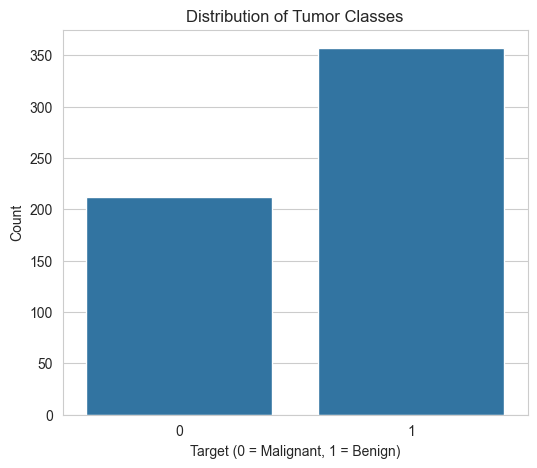

In [6]:
plt.figure(figsize=(6,5))
sns.countplot(x='target', data=df)

plt.title("Distribution of Tumor Classes")
plt.xlabel("Target (0 = Malignant, 1 = Benign)")
plt.ylabel("Count")

plt.show()

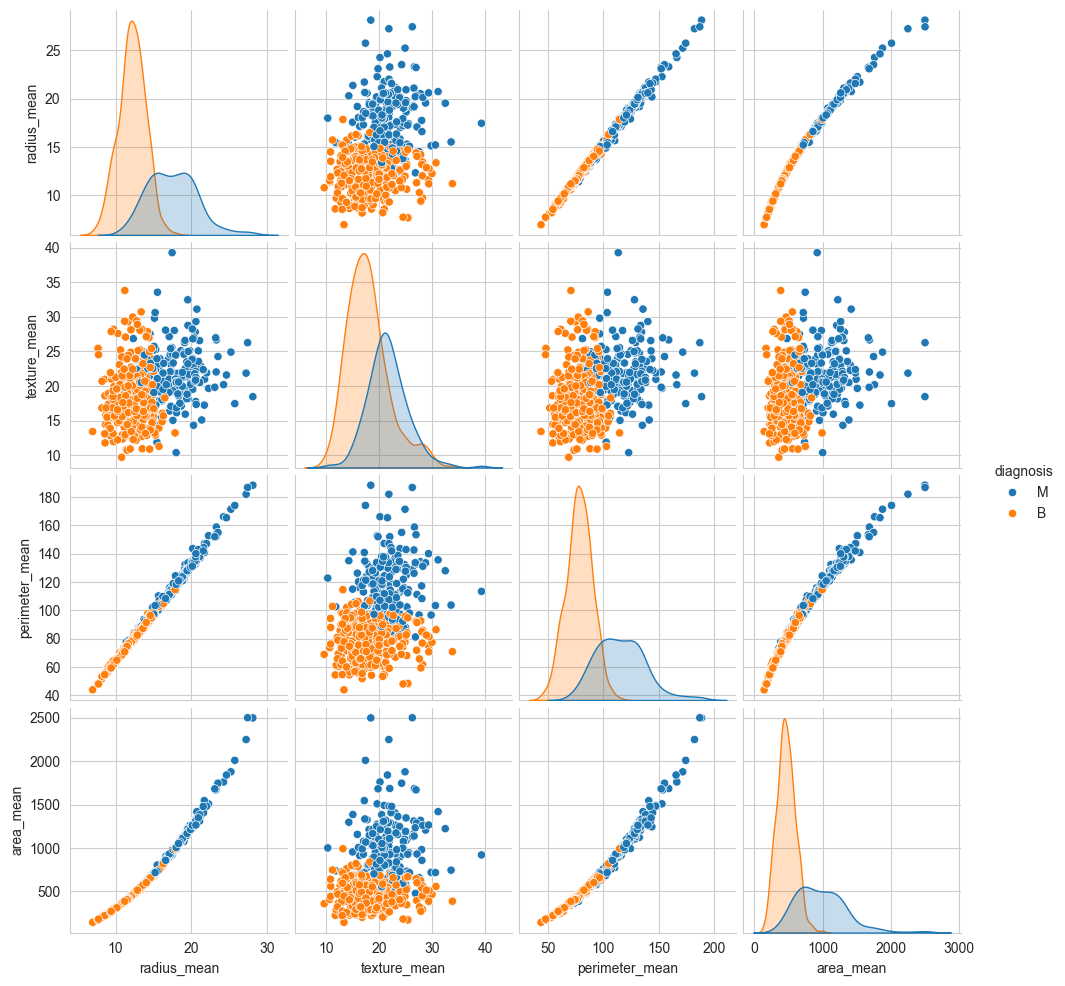

In [7]:
sns.pairplot(
    df[['radius_mean','texture_mean','perimeter_mean','area_mean','diagnosis']],
    hue='diagnosis',
    diag_kind='kde'
)

plt.show()

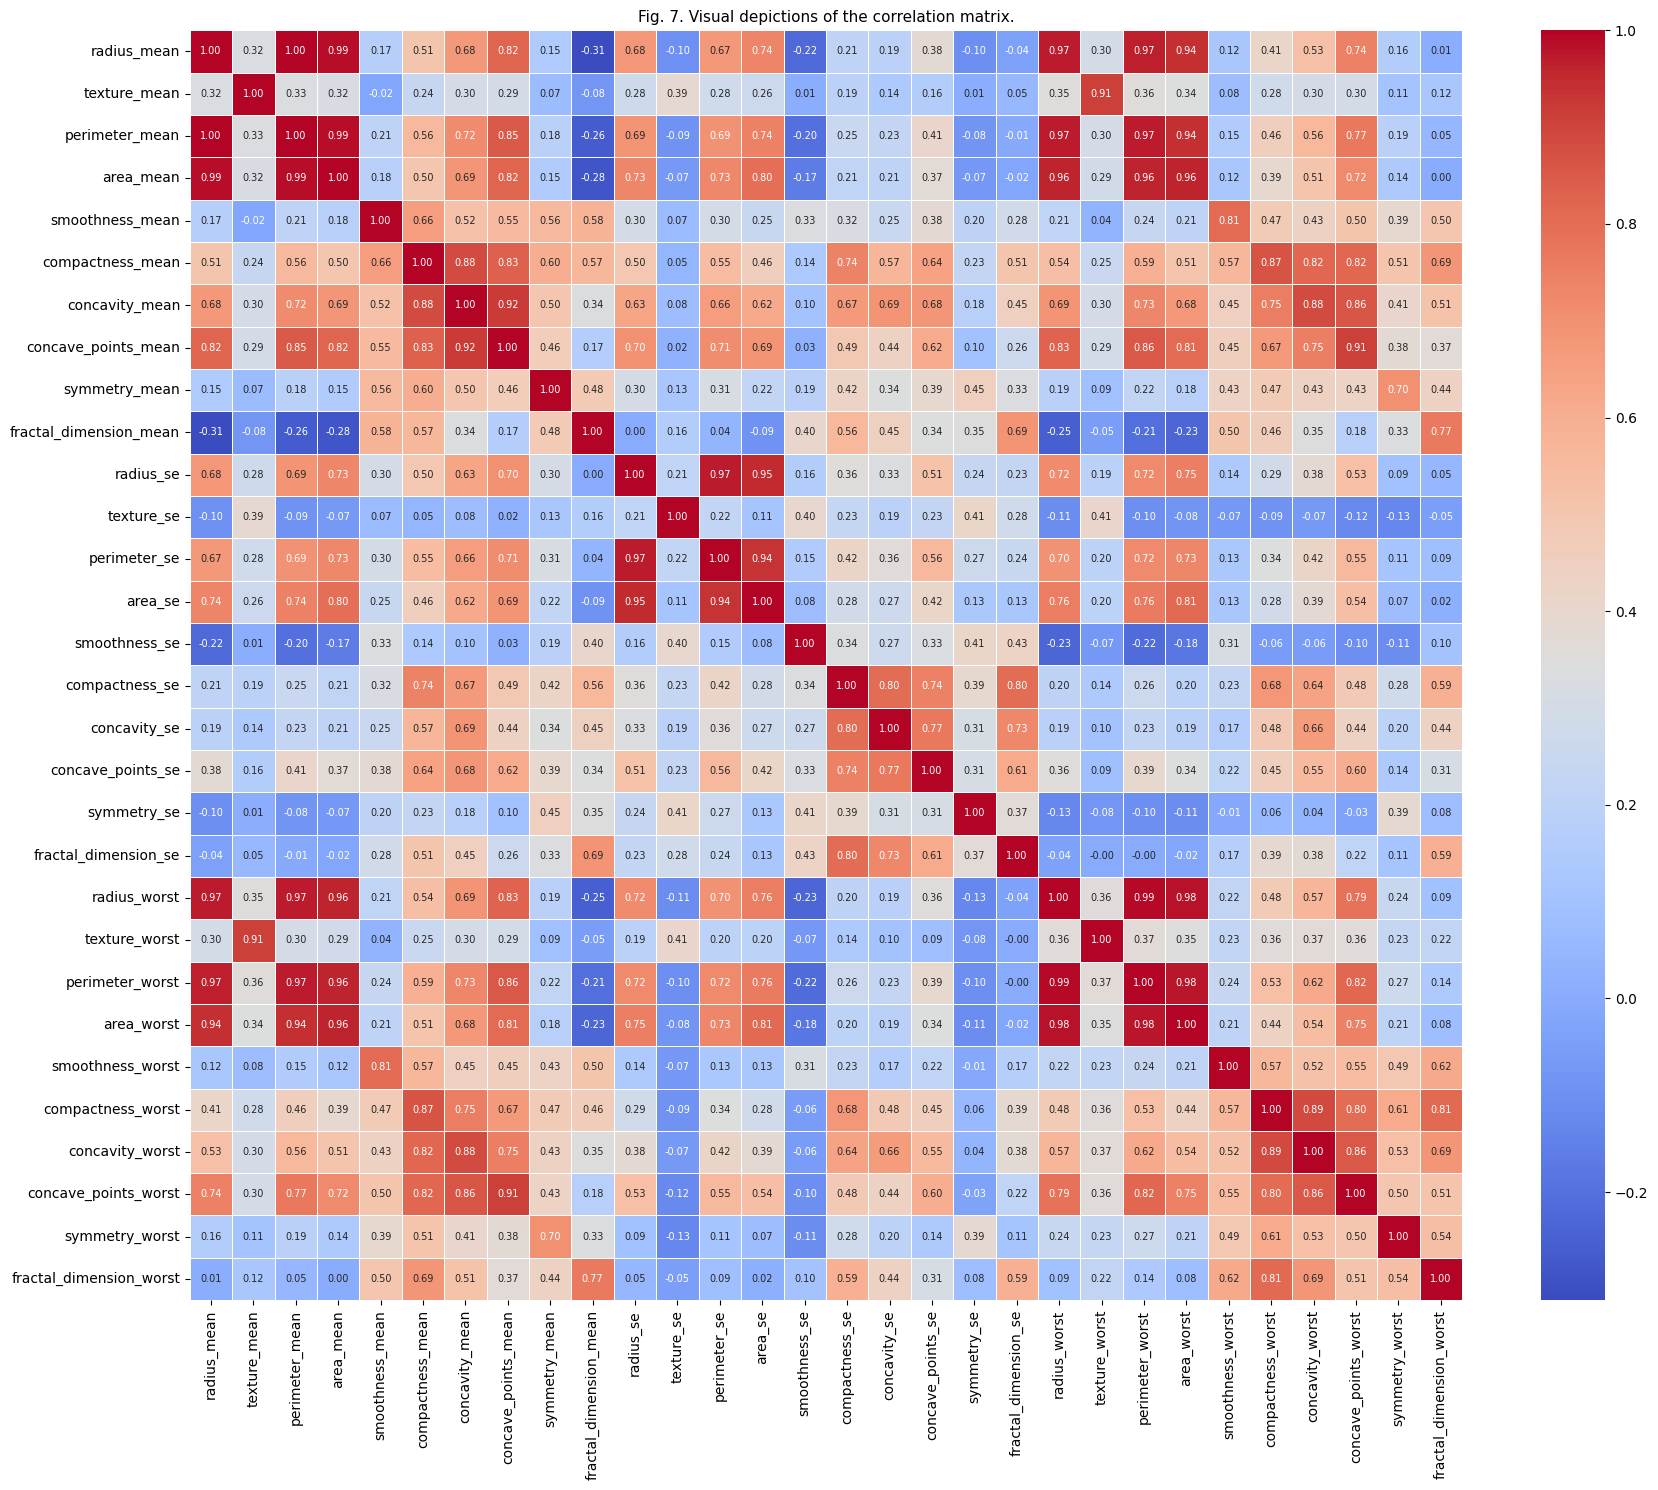

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("breast_cancer_dataset1.xlsx")
df.columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})

plt.figure(figsize=(18, 15))
corr = df.drop(columns=['id', 'diagnosis', 'target']).corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.5)
plt.title("Fig. 7. Visual depictions of the correlation matrix.", fontsize=11)
plt.tight_layout()
plt.show()

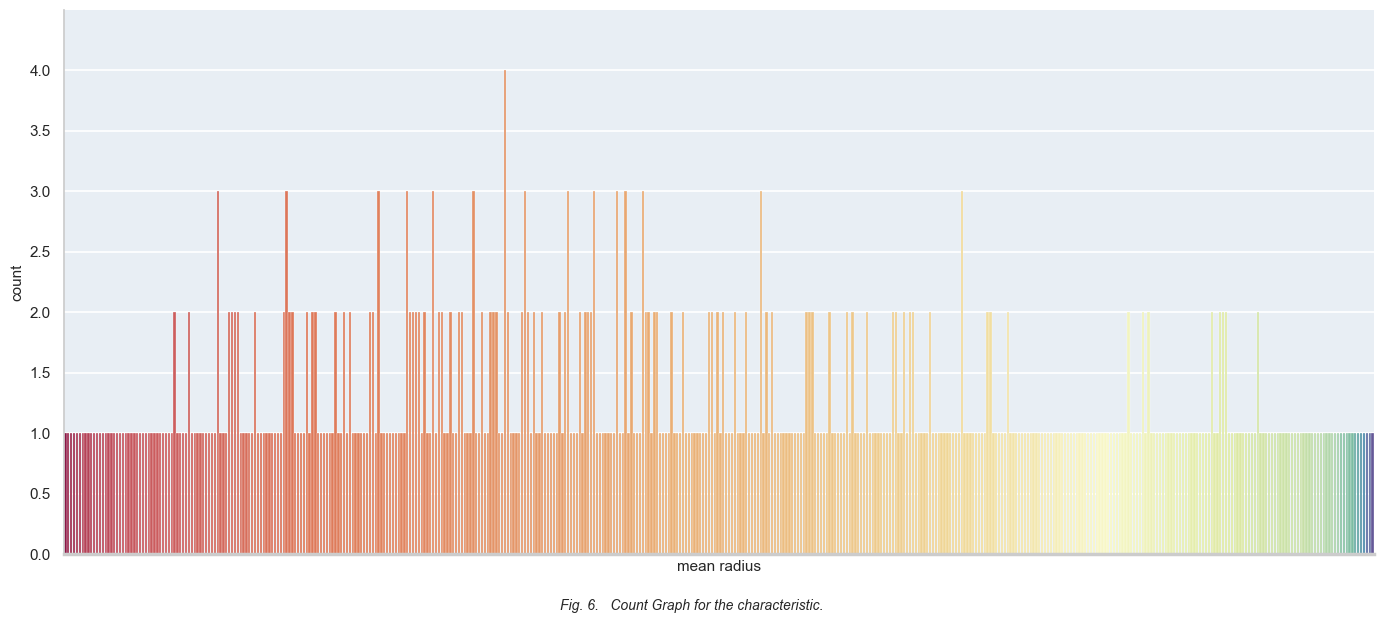

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("breast_cancer_dataset1.xlsx")
df.columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})

# paper approach: sns.countplot on raw radius_mean
# seaborn treats each unique float as a category (ordinal positions)
# no rounding, no manual value_counts — dataset drives everything

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.facecolor": "#E8EEF4",
    "figure.facecolor": "white",
    "grid.color": "white",
    "grid.linewidth": 1.2,
})

plt.figure(figsize=(14, 6))

ax = sns.countplot(
    x='radius_mean',
    data=df,
    hue='radius_mean',
    palette="Spectral",
    legend=False,
    linewidth=0.2,
    edgecolor="white"
)

ax.set_axisbelow(True)
ax.set_xticks([])
ax.set_xlabel("mean radius", fontsize=11)
ax.set_ylabel("count", fontsize=11)

# y-axis 0.0 to 4.0 with 0.5 steps — derived from dataset max count = 4
ax.set_ylim(0, 4.5)
ax.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_linewidth(2.5)

plt.figtext(0.5, -0.03, "Fig. 6.   Count Graph for the characteristic.",
            ha="center", fontsize=10, style="italic")
plt.tight_layout()
plt.show()

In [1]:
# Define all models with proper hyperparameters (no overfitting)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# sub-models for I-XGBoost voting classifier
rf_sub  = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
ada_sub = AdaBoostClassifier(n_estimators=10, learning_rate=0.1, random_state=42)
xgb_sub = XGBClassifier(n_estimators=100, max_depth=3, random_state=42,
                         eval_metric='logloss', verbosity=0)

models = {
    'Support Vector Machine (SVM)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Logistic Regression (LR)':     LogisticRegression(max_iter=10000, random_state=42),
    'K-Nearest Neighbors (KNN)':    KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes (NB)':             GaussianNB(),
    'Decision Tree (DT)':           DecisionTreeClassifier(criterion='gini',
                                        max_depth=3, random_state=42),
    'Random Forest (RF)':           RandomForestClassifier(n_estimators=100,
                                        max_depth=3, random_state=42),
    'AdaBoost,':                    AdaBoostClassifier(n_estimators=10,
                                        learning_rate=0.1, random_state=42),
    'XGBoost':                      XGBClassifier(n_estimators=100, max_depth=3,
                                        random_state=42, eval_metric='logloss',
                                        verbosity=0),
    'I-XGBoost':                    VotingClassifier(
                                        estimators=[('rf', rf_sub),
                                                    ('ada', ada_sub),
                                                    ('xgb', xgb_sub)],
                                        voting='hard')
}

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_excel("breast_cancer_dataset1.xlsx")
df.columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})

X = df.drop(columns=['id', 'diagnosis', 'target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 455
Test size : 114


In [4]:
# Train all models and print Table 1
import numpy as np
from sklearn.metrics import accuracy_score

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    tr = round(accuracy_score(y_train, model.predict(X_train)) * 100, 2)
    te = round(accuracy_score(y_test,  model.predict(X_test))  * 100, 2)
    results.append({'Algorithms': name,
                    'Accuracy training set (%)': tr,
                    'Accuracy testing set (%)':  te})

res = pd.DataFrame(results)

print("Table 1")
print("Accuracy percentage for breast cancer diagnostic dataset.\n")
print(res.to_string(index=False))

Table 1
Accuracy percentage for breast cancer diagnostic dataset.

                  Algorithms  Accuracy training set (%)  Accuracy testing set (%)
Support Vector Machine (SVM)                      98.46                     97.37
    Logistic Regression (LR)                      98.90                     97.37
   K-Nearest Neighbors (KNN)                      97.36                     97.37
            Naive Bayes (NB)                      93.41                     93.86
          Decision Tree (DT)                      96.70                     93.86
          Random Forest (RF)                      97.58                     97.37
                   AdaBoost,                      94.51                     94.74
                     XGBoost                     100.00                     96.49
                   I-XGBoost                      98.02                     97.37


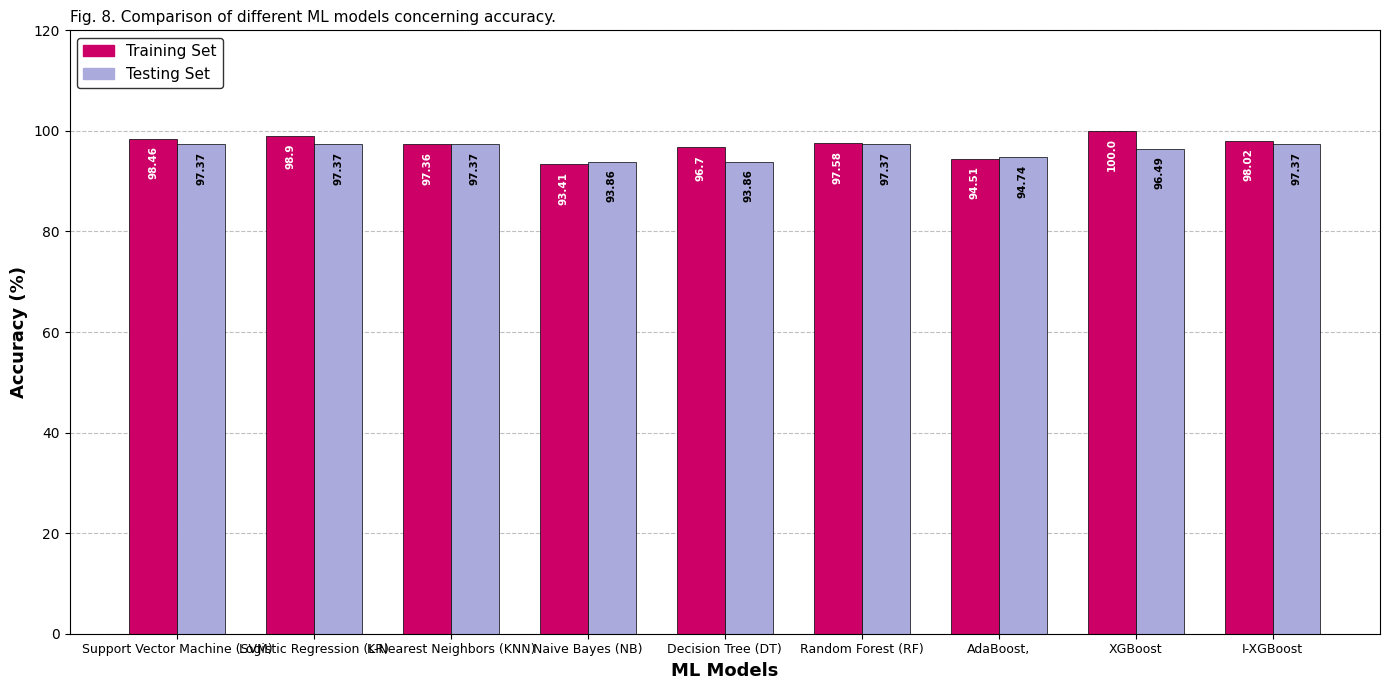

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels     = list(res['Algorithms'])
train_vals = res['Accuracy training set (%)'].values
test_vals  = res['Accuracy testing set (%)'].values

x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

b1 = ax.bar(x - w/2, train_vals, w, color='#CC0066', edgecolor='black', linewidth=0.5)
b2 = ax.bar(x + w/2, test_vals,  w, color='#AAAADD', edgecolor='black', linewidth=0.5)

for bar, val in zip(b1, train_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            str(val), ha='center', va='top', fontsize=7.5,
            rotation=90, color='white', fontweight='bold')

for bar, val in zip(b2, test_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 1.5,
            str(val), ha='center', va='top', fontsize=7.5,
            rotation=90, color='black', fontweight='bold')

ax.set_ylim(0, 120)
ax.set_yticks([0, 20, 40, 60, 80, 100, 120])
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_xlabel('ML Models', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
ax.set_axisbelow(True)

ax.legend(handles=[
    mpatches.Patch(color='#CC0066', label='Training Set'),
    mpatches.Patch(color='#AAAADD', label='Testing Set')
], fontsize=11, loc='upper left', frameon=True, edgecolor='black')

plt.title('Fig. 8. Comparison of different ML models concerning accuracy.',
          fontsize=11, loc='left')
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from xgboost import XGBClassifier

df = pd.read_excel("breast_cancer_dataset1.xlsx")
df.columns = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]
df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})

X = df.drop(columns=['id', 'diagnosis', 'target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

rf_sub  = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
ada_sub = AdaBoostClassifier(n_estimators=10, learning_rate=0.1, random_state=42)
xgb_sub = XGBClassifier(n_estimators=100, max_depth=3, random_state=42,
                         eval_metric='logloss', verbosity=0)

models = {
    'Support Vector Machine (SVM)': SVC(kernel='rbf', C=1.0, random_state=42),
    'Logistic Regression (LR)':     LogisticRegression(max_iter=10000, random_state=42),
    'K-Nearest Neighbors (KNN)':    KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes (NB)':             GaussianNB(),
    'Decision Tree (DT)':           DecisionTreeClassifier(criterion='gini',
                                        max_depth=3, random_state=42),
    'Random Forest (RF)':           RandomForestClassifier(n_estimators=100,
                                        max_depth=3, random_state=42),
    'AdaBoost,':                    AdaBoostClassifier(n_estimators=10,
                                        learning_rate=0.1, random_state=42),
    'XGBoost':                      XGBClassifier(n_estimators=100, max_depth=3,
                                        random_state=42, eval_metric='logloss',
                                        verbosity=0),
    'I-XGBoost':                    VotingClassifier(
                                        estimators=[('rf',  rf_sub),
                                                    ('ada', ada_sub),
                                                    ('xgb', xgb_sub)],
                                        voting='hard')
}

for name, model in models.items():
    model.fit(X_train, y_train)

rows = []
for name, model in models.items():
    preds = model.predict(X_test)
    for cls, label in [(1, 'Benign'), (0, 'Malignant')]:
        rows.append({
            'Algorithm': name,
            'Class':     label,
            'Precision': round(precision_score(y_test, preds, pos_label=cls, zero_division=0), 2),
            'Recall':    round(recall_score(y_test,    preds, pos_label=cls, zero_division=0), 2),
            'F1-Score':  round(f1_score(y_test,        preds, pos_label=cls, zero_division=0), 2),
        })

metrics_df = pd.DataFrame(rows)

print("Table 2")
print("Classifiers performances.\n")
print(f"{'':35} {'Precision':>10} {'Recall':>8} {'F1-Score':>10} {'Class':>12}")
print("-" * 78)

for name in models:
    sub   = metrics_df[metrics_df['Algorithm'] == name]
    first = True
    for _, r in sub.iterrows():
        lbl = name if first else ''
        print(f"{lbl:<35} {r['Precision']:>10} {r['Recall']:>8} {r['F1-Score']:>10} {r['Class']:>12}")
        first = False
    print()

Table 2
Classifiers performances.

                                     Precision   Recall   F1-Score        Class
------------------------------------------------------------------------------
Support Vector Machine (SVM)              0.99     0.97       0.98       Benign
                                          0.95     0.98       0.96    Malignant

Logistic Regression (LR)                  0.97     0.99       0.98       Benign
                                          0.98     0.95       0.96    Malignant

K-Nearest Neighbors (KNN)                 0.96      1.0       0.98       Benign
                                           1.0     0.93       0.96    Malignant

Naive Bayes (NB)                          0.96     0.94       0.95       Benign
                                          0.91     0.93       0.92    Malignant

Decision Tree (DT)                        0.92     0.99       0.95       Benign
                                          0.97     0.86       0.91    Malignant

R

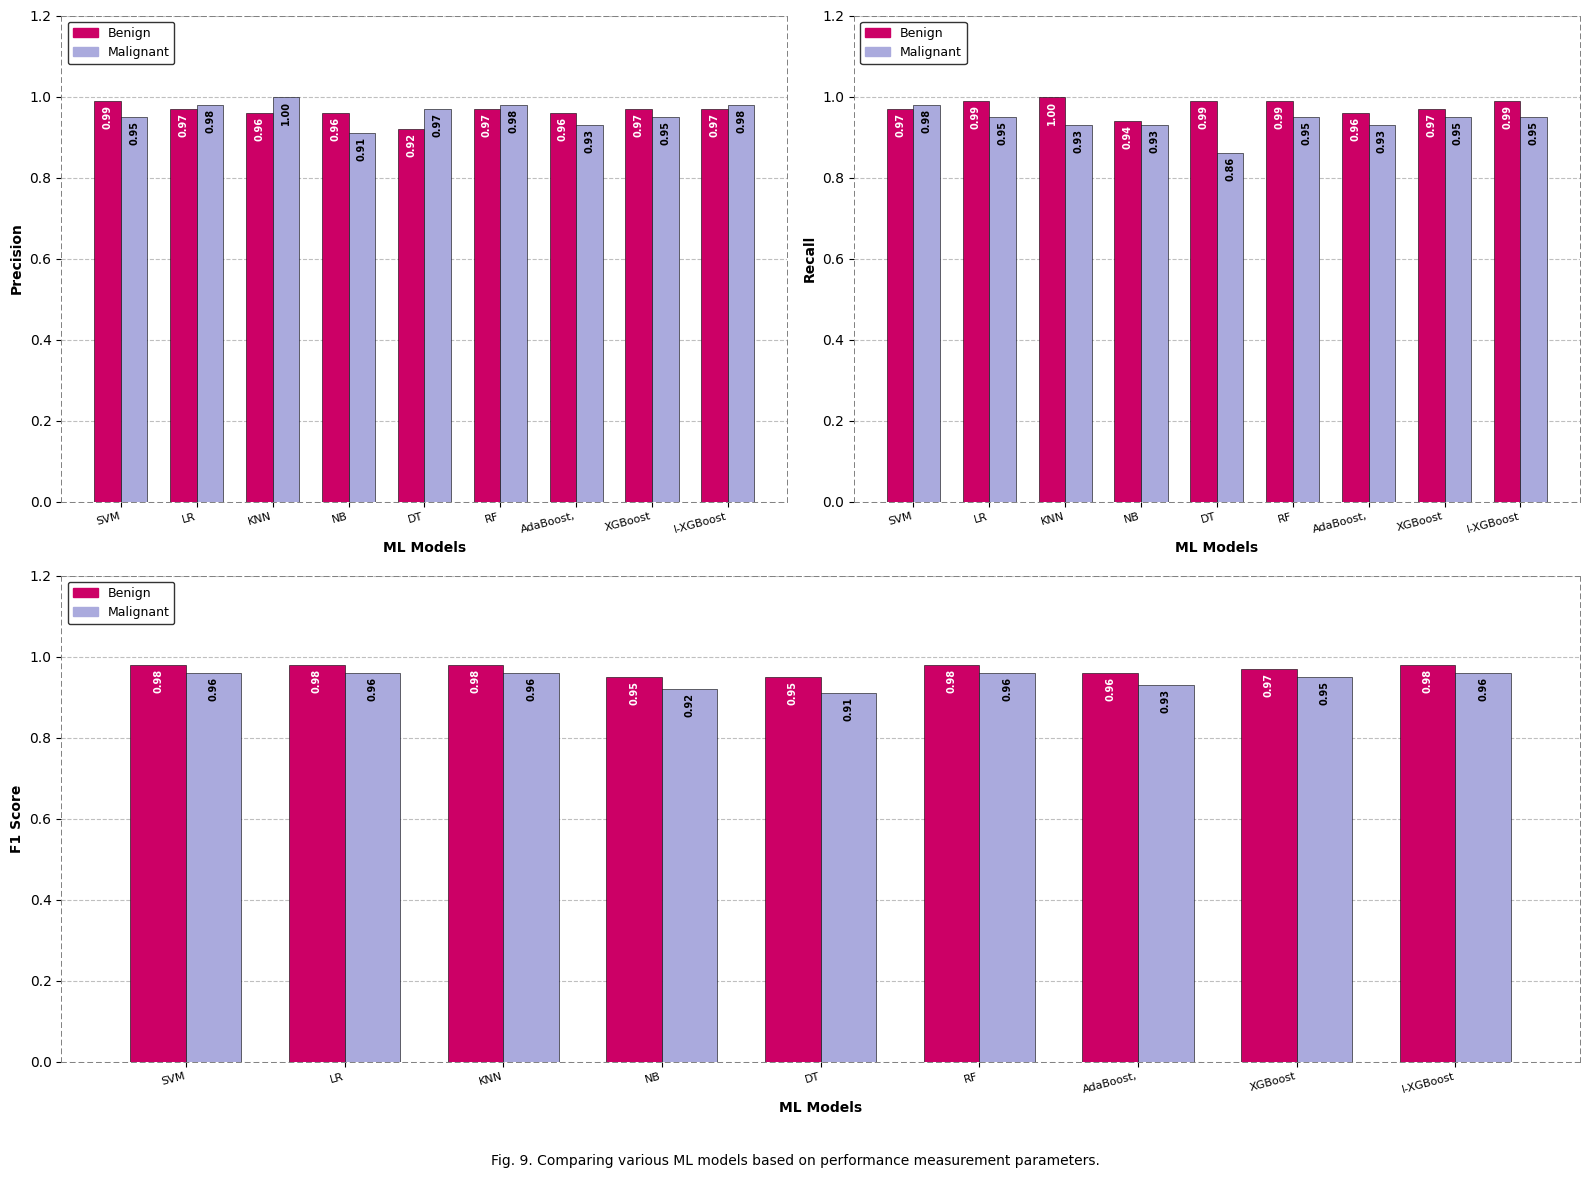

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PINK   = '#CC0066'
PURPLE = '#AAAADD'

benign_df    = metrics_df[metrics_df['Class'] == 'Benign'].reset_index(drop=True)
malignant_df = metrics_df[metrics_df['Class'] == 'Malignant'].reset_index(drop=True)

short_names = ['SVM', 'LR', 'KNN', 'NB', 'DT', 'RF', 'AdaBoost,', 'XGBoost', 'I-XGBoost']
x = np.arange(len(short_names))
w = 0.35

def add_labels(ax, bars, color):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h - 0.01,
                f'{h:.2f}', ha='center', va='top',
                fontsize=7, rotation=90, color=color, fontweight='bold')

def style_ax(ax, ylabel):
    ax.set_ylim(0, 1.2)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_linestyle((0, (5, 4)))
        sp.set_linewidth(0.7)
        sp.set_color('gray')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names, fontsize=8, rotation=15, ha='right')
    ax.set_xlabel('ML Models', fontsize=10, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10, fontweight='bold')
    ax.legend(handles=[
        mpatches.Patch(color=PINK,   label='Benign'),
        mpatches.Patch(color=PURPLE, label='Malignant')
    ], fontsize=9, loc='upper left', frameon=True, edgecolor='black')

fig = plt.figure(figsize=(16, 12))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 1, 2)

for ax, metric, ylabel in [
    (ax1, 'Precision', 'Precision'),
    (ax2, 'Recall',    'Recall'),
    (ax3, 'F1-Score',  'F1 Score')
]:
    b1 = ax.bar(x - w/2, benign_df[metric].values,    w,
                color=PINK,   edgecolor='black', linewidth=0.4)
    b2 = ax.bar(x + w/2, malignant_df[metric].values, w,
                color=PURPLE, edgecolor='black', linewidth=0.4)
    add_labels(ax, b1, 'white')
    add_labels(ax, b2, 'black')
    style_ax(ax, ylabel)

plt.suptitle(
    'Fig. 9. Comparing various ML models based on performance measurement parameters.',
    fontsize=10, y=0.01)
plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.show()